# Debugging ebeam fracturing

This notebook parses a plain-text fracture dump where each polygon is preceded by a header line (e.g. 1 100.0 0) and followed by its vertices in the exposure/meander order. Polygons are separated by blank lines or a line containing #. It plots:

- overall exposure order (color = polygon index)
- meander path inside each polygon, including step numbers and arrows

Update data_path in the first code cell to point to your fracture text file.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Path to the fracture text file
data_path = Path('fracture_output.txt')  # <- change to your file

In [2]:
def parse_fracture_file(path: Path):
    # Parse fracture file into a list of polygons (each a list of (x, y)).
    # Rules:
    # - Skip header lines with three tokens (e.g. '1 100.0 0').
    # - Treat blank lines or lines starting with '#' as polygon separators.
    # - Keep vertex order as written (exposure order).
    polygons, current = [], []
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line:
            if current:
                polygons.append(current)
                current = []
            continue
        if line.startswith('#'):
            if current:
                polygons.append(current)
                current = []
            continue

        parts = line.split()
        if len(parts) == 3:
            # header line: device id, dose, etc.
            continue

        if len(parts) >= 2:
            try:
                x, y = float(parts[0]), float(parts[1])
            except ValueError:
                continue
            current.append((x, y))

    if current:
        polygons.append(current)

    # Close polygons if last point is not identical to first
    closed = []
    for pts in polygons:
        if pts and (abs(pts[0][0] - pts[-1][0]) > 1e-9 or abs(pts[0][1] - pts[-1][1]) > 1e-9):
            pts = pts + [pts[0]]
            print('Polygon not closed!')
        closed.append(pts)
    return closed

In [3]:
def plot_exposure(polygons, annotate_poly_order=True, annotate_path=True, arrows=True, figsize=(8, 8)):
    # Visualize polygon exposure order and meander path.
    if not polygons:
        raise ValueError('No polygons parsed; check data_path or file format.')

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap('plasma', len(polygons))

    for idx, pts in enumerate(polygons):
        arr = np.asarray(pts)
        color = cmap(idx)

        # polygon outline/fill
        ax.add_patch(Polygon(arr, closed=True, facecolor=color, alpha=0.18,
                             edgecolor=color, linewidth=1.5))
        ax.plot(arr[:, 0], arr[:, 1], color=color, lw=1.2, marker='o', markersize=3)

        # label polygon order at centroid
        if annotate_poly_order:
            body = arr[:-1] if len(arr) > 1 else arr
            centroid = body.mean(axis=0)
            ax.text(centroid[0], centroid[1], f'{idx + 1}', fontsize=9, weight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, lw=0.8, alpha=0.9))

        # annotate meander sequence inside polygon
        if annotate_path:
            for j in range(len(arr) - 1):
                ax.text(arr[j, 0], arr[j, 1], str(j + 1), color='black', fontsize=7, ha='center', va='center')
                if arrows:
                    ax.annotate('', xy=arr[j + 1], xytext=arr[j],
                                arrowprops=dict(arrowstyle='->', color=color, lw=1.0, shrinkA=1, shrinkB=1))

    ax.set_xlabel('x (?m)')
    ax.set_ylabel('y (?m)')
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, ls='--', alpha=0.3)
    plt.tight_layout()
    return fig, ax

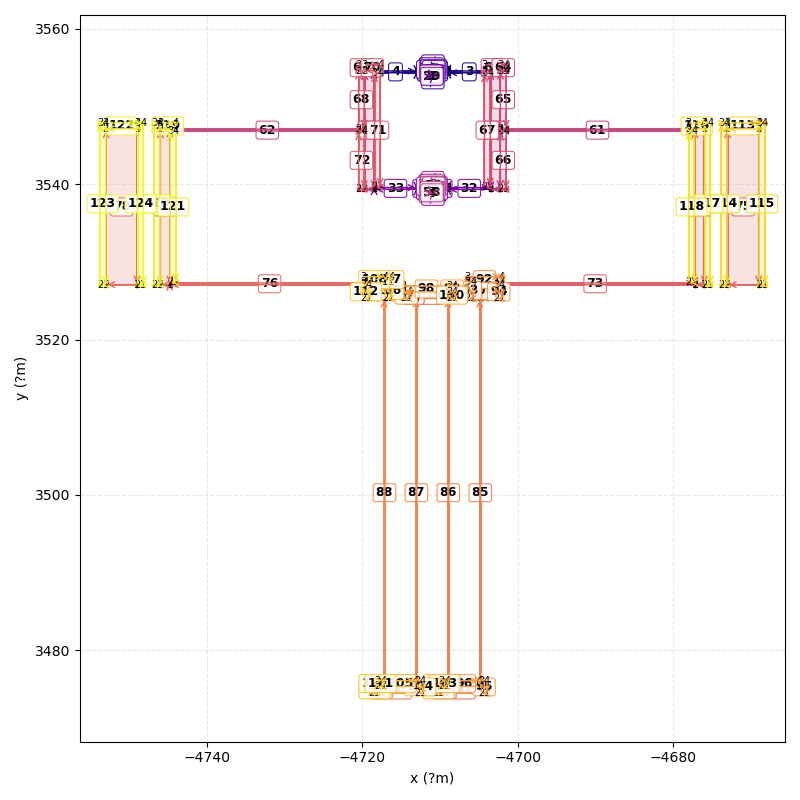

In [4]:
%matplotlib widget
# Parse and plot
polygons = parse_fracture_file(data_path)
fig, ax = plot_exposure(polygons)
plt.show()

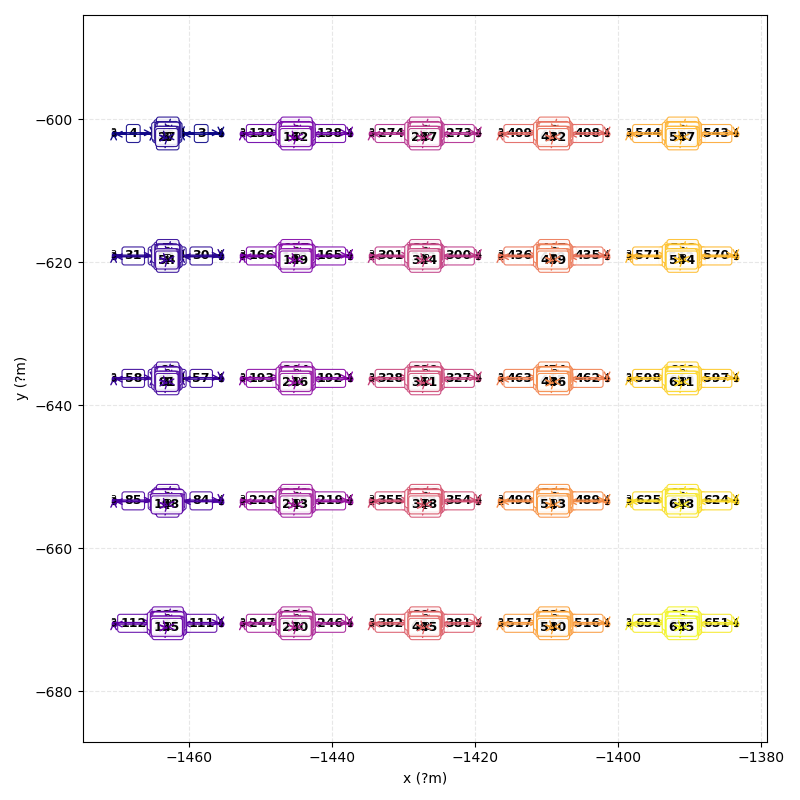

In [7]:
%matplotlib widget
# Parse and plot
data_path = Path('ExpoDebug_D00.txt')

polygons = parse_fracture_file(data_path)
fig, ax = plot_exposure(polygons)
plt.show()

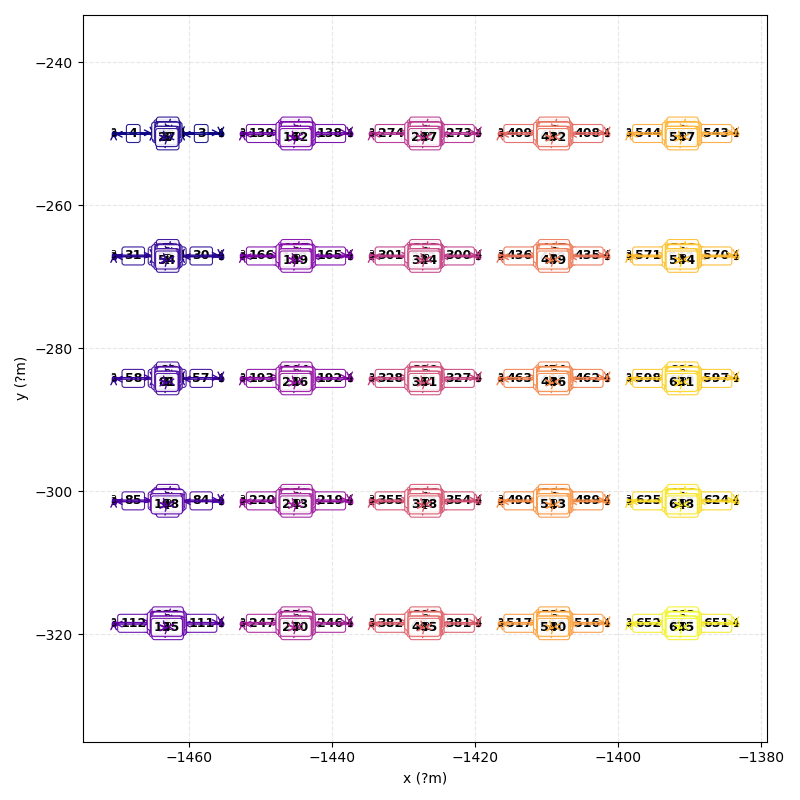

In [8]:
%matplotlib widget
# Parse and plot
data_path = Path('ExpoDebug_D20.txt')

polygons = parse_fracture_file(data_path)
fig, ax = plot_exposure(polygons)
plt.show()

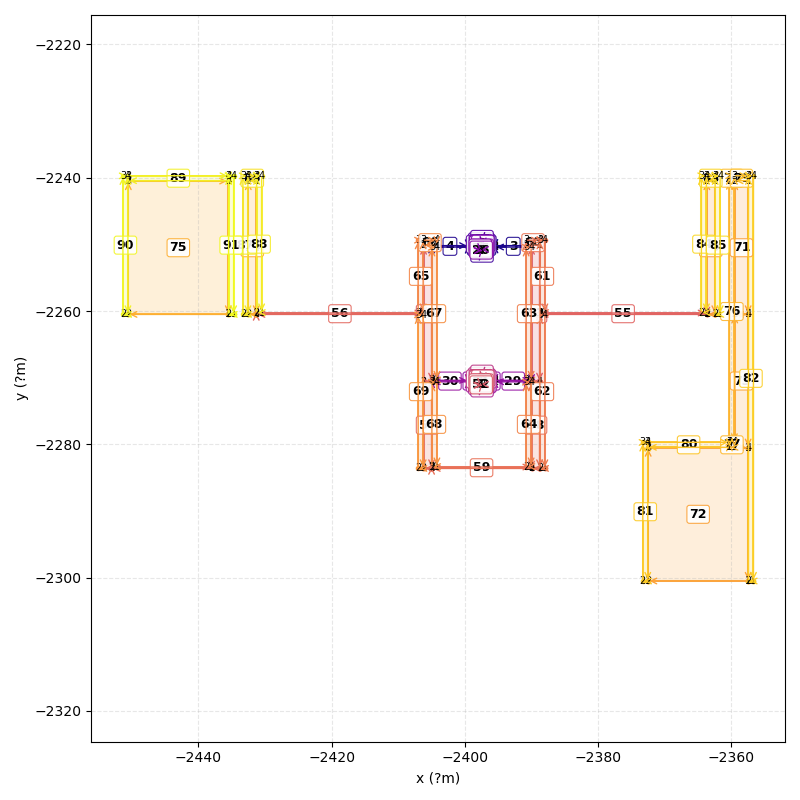

In [9]:
%matplotlib widget
# Parse and plot
data_path = Path('ExpoDebug_Bot1.txt')

polygons = parse_fracture_file(data_path)
fig, ax = plot_exposure(polygons)
plt.show()

In [26]:

# PyQt clickable/zoomable viewer (run after polygons is defined)
import sys
from PyQt5 import QtWidgets, QtGui, QtCore

COSMETIC_PEN_WIDTH = 1.2  # screen-space width regardless of zoom

class PolyItem(QtWidgets.QGraphicsPolygonItem):
    def __init__(self, points, idx):
        super().__init__(QtGui.QPolygonF([QtCore.QPointF(x, y) for x, y in points]))
        self.idx = idx  # zero-based index in file order
        self.points = points

        pen = QtGui.QPen(QtGui.QColor(30, 60, 160), COSMETIC_PEN_WIDTH)
        pen.setCosmetic(True)  # keeps thickness constant while zooming
        pen.setJoinStyle(QtCore.Qt.MiterJoin)
        self.setPen(pen)
        self.setBrush(QtGui.QColor(60, 120, 255, 60))

        self.setAcceptHoverEvents(True)
        self.setFlag(QtWidgets.QGraphicsItem.ItemIsSelectable, True)

    # Use fill-only shape for hit-testing so hover/click only triggers when cursor is actually over the polygon
    def shape(self):
        path = QtGui.QPainterPath()
        path.addPolygon(self.polygon())
        return path

    def mousePressEvent(self, event):
        file_order = self.idx + 1
        lines = [f'Vertices:\n']
        lines += [f'{i+1}: ({x}, {y})\n' for i, (x, y) in enumerate(self.points)]
        QtWidgets.QMessageBox.information(None,
                                          f'Polygon {file_order}',
                                          ''.join(lines))
        super().mousePressEvent(event)

    def hoverEnterEvent(self, event):
        self.setBrush(QtGui.QColor(255, 180, 60, 90))
        super().hoverEnterEvent(event)

    def hoverLeaveEvent(self, event):
        self.setBrush(QtGui.QColor(60, 120, 255, 60))
        super().hoverLeaveEvent(event)


def _nice_length(value):
    """Round value to 1, 2, or 5 * 10^n for a clean scale bar label."""
    import math
    if value == 0:
        return 0
    exp = math.floor(math.log10(abs(value)))
    base = value / (10 ** exp)
    if base < 1.5:
        nice = 1
    elif base < 3.5:
        nice = 2
    elif base < 7.5:
        nice = 5
    else:
        nice = 10
    return nice * (10 ** exp)

class ZoomableView(QtWidgets.QGraphicsView):
    def __init__(self, scene):
        super().__init__(scene)
        self.setRenderHint(QtGui.QPainter.Antialiasing)
        self.setRenderHint(QtGui.QPainter.TextAntialiasing)
        self.setDragMode(QtWidgets.QGraphicsView.ScrollHandDrag)
        self.setTransformationAnchor(QtWidgets.QGraphicsView.AnchorUnderMouse)
        self.setViewportUpdateMode(QtWidgets.QGraphicsView.BoundingRectViewportUpdate)
        self.setMouseTracking(True)

    def wheelEvent(self, event):
        factor = 1.15 if event.angleDelta().y() > 0 else 1/1.15
        self.scale(factor, factor)

    def drawForeground(self, painter, rect):
        # overlay scale bar in viewport coords so it stays put while panning/zooming
        painter.save()

        # compute scene units per pixel using current transform
        sx = self.transform().m11()  # includes sign from y flip
        scene_per_px = 1.0 / abs(sx) if sx != 0 else 0
        target_px = 120
        raw_len = scene_per_px * target_px
        nice_len = _nice_length(raw_len)
        if nice_len == 0:
            painter.restore(); return
        bar_px = nice_len / scene_per_px

        painter.resetTransform()  # draw in viewport coords
        painter.setClipRect(self.viewport().rect())  # ensure not clipped by scene pan

        margin = 14
        x0 = margin
        x1 = x0 + bar_px
        y = self.viewport().height() - margin

        pen = QtGui.QPen(QtGui.QColor(20, 20, 20), 1.0)
        pen.setCosmetic(True)
        painter.setPen(pen)
        painter.drawLine(QtCore.QPointF(x0, y), QtCore.QPointF(x1, y))
        painter.drawLine(QtCore.QPointF(x0, y-4), QtCore.QPointF(x0, y+4))
        painter.drawLine(QtCore.QPointF(x1, y-4), QtCore.QPointF(x1, y+4))

        label = f'{nice_len:g} µm'
        font = QtGui.QFont('Arial', 9)
        painter.setFont(font)
        fm = QtGui.QFontMetrics(font)
        text_width = fm.horizontalAdvance(label)
        text_x = x0 + (bar_px - text_width) / 2
        painter.drawText(QtCore.QPointF(text_x, y - 8), label)

        painter.restore()

class PolyViewer(QtWidgets.QMainWindow):
    def __init__(self, polygons):
        super().__init__()
        self.setWindowTitle('Fracture Viewer (click polygons)')
        scene = QtWidgets.QGraphicsScene(self)

        xs = [x for poly in polygons for x, _ in poly]
        ys = [y for poly in polygons for _, y in poly]
        margin = 10
        scene.setSceneRect(min(xs)-margin, min(ys)-margin,
                           (max(xs)-min(xs))+2*margin,
                           (max(ys)-min(ys))+2*margin)

        for idx, pts in enumerate(polygons):
            scene.addItem(PolyItem(pts, idx))

        view = ZoomableView(scene)
        view.scale(1, -1)  # keep y upward like layout coords
        view.fitInView(scene.sceneRect(), QtCore.Qt.KeepAspectRatio)

        self.setCentralWidget(view)
        self.statusBar().showMessage('Scroll to zoom; drag to pan; click polygon for details')


def launch_qt_viewer(polygons):
    if not polygons:
        print('No polygons parsed; run the parser cell first.')
        return
    app = QtWidgets.QApplication.instance()
    owns = False
    if app is None:
        app = QtWidgets.QApplication(sys.argv)
        owns = True
    win = PolyViewer(polygons)
    win.resize(900, 900)
    win.show()
    if owns:
        app.exec_()

launch_qt_viewer(polygons)  # uncomment to run


In [31]:

# PyQt viewer with centered polygon indices
import sys
from PyQt5 import QtWidgets, QtGui, QtCore

data_path = Path('ExpoDebug_D20.txt')

# Reuse COSMETIC_PEN_WIDTH and color_for if already defined; otherwise set fallbacks
# try:
#     COSMETIC_PEN_WIDTH
# except NameError:
COSMETIC_PEN_WIDTH = 1.2

# try:
#     color_for
# except NameError:
def color_for(idx, total):
    if total <= 1:
        return QtGui.QColor(60, 120, 255, 160), QtGui.QColor(30, 60, 160)
    hue = 0.08 + 0.75 * idx / max(total - 1, 1)
    fill = QtGui.QColor.fromHsvF(hue % 1.0, 0.7, 0.95, 0.55)
    edge = QtGui.QColor.fromHsvF(hue % 1.0, 0.8, 0.8, 1.0)
    return fill, edge

def polygon_centroid(points):
    # points list of (x,y); assumes non-self-intersecting polygon and closed or open list
    if len(points) < 3:
        return points[0] if points else (0, 0)
    pts = points
    if pts[0] != pts[-1]:
        pts = pts + [pts[0]]
    a = 0
    cx = 0
    cy = 0
    for i in range(len(pts) - 1):
        x0, y0 = pts[i]
        x1, y1 = pts[i + 1]
        cross = x0 * y1 - x1 * y0
        a += cross
        cx += (x0 + x1) * cross
        cy += (y0 + y1) * cross
    if abs(a) < 1e-12:
        # degenerate; fallback to average
        xs, ys = zip(*points)
        return (sum(xs) / len(xs), sum(ys) / len(ys))
    a *= 0.5
    cx /= (6 * a)
    cy /= (6 * a)
    return (cx, cy)

class PolyItemC(QtWidgets.QGraphicsPolygonItem):
    def __init__(self, points, idx, fill_color, edge_color):
        super().__init__(QtGui.QPolygonF([QtCore.QPointF(x, y) for x, y in points]))
        self.idx = idx
        self.points = points
        pen = QtGui.QPen(edge_color, COSMETIC_PEN_WIDTH)
        pen.setCosmetic(True)
        pen.setJoinStyle(QtCore.Qt.MiterJoin)
        self.setPen(pen)
        self.base_fill = fill_color
        self.setBrush(self.base_fill)
        self.setAcceptHoverEvents(True)
        self.setFlag(QtWidgets.QGraphicsItem.ItemIsSelectable, True)

    def shape(self):
        path = QtGui.QPainterPath()
        path.addPolygon(self.polygon())
        return path

    def mousePressEvent(self, event):
        file_order = self.idx + 1
        lines = [f'Vertices:\n']
        lines += [f'{i+1}: ({x}, {y})\n' for i, (x, y) in enumerate(self.points)]
        QtWidgets.QMessageBox.information(None,
                                          f'Polygon {file_order}',
                                          ''.join(lines))
        super().mousePressEvent(event)

    def hoverEnterEvent(self, event):
        self.setBrush(QtGui.QColor(255, 180, 60, 90))
        super().hoverEnterEvent(event)

    def hoverLeaveEvent(self, event):
        self.setBrush(self.base_fill)
        super().hoverLeaveEvent(event)

class ZoomableViewC(QtWidgets.QGraphicsView):
    def __init__(self, scene):
        super().__init__(scene)
        self.setRenderHint(QtGui.QPainter.Antialiasing)
        self.setRenderHint(QtGui.QPainter.TextAntialiasing)
        self.setDragMode(QtWidgets.QGraphicsView.ScrollHandDrag)
        self.setTransformationAnchor(QtWidgets.QGraphicsView.AnchorUnderMouse)
        self.setViewportUpdateMode(QtWidgets.QGraphicsView.FullViewportUpdate)
        self.setMouseTracking(True)
        self.label_entries = []

    def wheelEvent(self, event):
        factor = 1.15 if event.angleDelta().y() > 0 else 1/1.15
        self.scale(factor, factor)
        self.update_label_positions()

    def resizeEvent(self, event):
        super().resizeEvent(event)
        self.update_label_positions()

    def update_label_positions(self):
        if not self.label_entries:
            return
        scale = abs(self.transform().m11()) if self.transform().m11() else 1.0
        scene_per_px = 1.0 / scale
        for poly, label in self.label_entries:
            centroid = polygon_centroid(poly.points)
            label.setPos(centroid[0] - (label.boundingRect().width() * scene_per_px) / 2,
                         centroid[1] - (label.boundingRect().height() * scene_per_px) / 2)
            rect = poly.mapToScene(poly.polygon()).boundingRect()
            text_w = label.boundingRect().width() * scene_per_px * 1.1
            text_h = label.boundingRect().height() * scene_per_px * 1.1
            fits = rect.width() >= text_w and rect.height() >= text_h
            label.setVisible(fits)

    def drawForeground(self, painter, rect):
        # overlay scale bar in viewport coords so it stays put while panning/zooming
        painter.save()

        # compute scene units per pixel using current transform
        sx = self.transform().m11()  # includes sign from y flip
        scene_per_px = 1.0 / abs(sx) if sx != 0 else 0
        target_px = 120
        raw_len = scene_per_px * target_px
        nice_len = _nice_length(raw_len)
        if nice_len == 0:
            painter.restore(); return
        bar_px = nice_len / scene_per_px

        painter.resetTransform()  # draw in viewport coords
        painter.setClipRect(self.viewport().rect())  # ensure not clipped by scene pan

        margin = 14
        x0 = margin
        x1 = x0 + bar_px
        y = self.viewport().height() - margin

        pen = QtGui.QPen(QtGui.QColor(20, 20, 20), 1.0)
        pen.setCosmetic(True)
        painter.setPen(pen)
        painter.drawLine(QtCore.QPointF(x0, y), QtCore.QPointF(x1, y))
        painter.drawLine(QtCore.QPointF(x0, y-4), QtCore.QPointF(x0, y+4))
        painter.drawLine(QtCore.QPointF(x1, y-4), QtCore.QPointF(x1, y+4))

        label = f'{nice_len:g} µm'
        font = QtGui.QFont('Arial', 9)
        painter.setFont(font)
        fm = QtGui.QFontMetrics(font)
        text_width = fm.horizontalAdvance(label)
        text_x = x0 + (bar_px - text_width) / 2
        painter.drawText(QtCore.QPointF(text_x, y - 8), label)

        painter.restore()

class PolyViewerCentered(QtWidgets.QMainWindow):
    def __init__(self, polygons):
        super().__init__()
        self.setWindowTitle('Fracture Viewer (centered labels)')
        scene = QtWidgets.QGraphicsScene(self)

        xs = [x for poly in polygons for x, _ in poly]
        ys = [y for poly in polygons for _, y in poly]
        margin = 10
        scene.setSceneRect(min(xs)-margin, min(ys)-margin,
                           (max(xs)-min(xs))+2*margin,
                           (max(ys)-min(ys))+2*margin)

        total = len(polygons)
        view = ZoomableViewC(scene)

        for idx, pts in enumerate(polygons):
            fill, edge = color_for(idx, total)
            poly_item = PolyItemC(pts, idx, fill, edge)
            scene.addItem(poly_item)

            label = QtWidgets.QGraphicsSimpleTextItem(str(idx + 1))
            label.setFont(QtGui.QFont('Arial', 10, QtGui.QFont.Bold))
            label.setBrush(QtGui.QBrush(QtGui.QColor(10, 10, 10)))
            label.setFlag(QtWidgets.QGraphicsItem.ItemIgnoresTransformations, True)
            scene.addItem(label)
            view.label_entries.append((poly_item, label))

        view.scale(1, -1)  # keep y upward like layout coords
        view.fitInView(scene.sceneRect(), QtCore.Qt.KeepAspectRatio)
        view.update_label_positions()

        self.setCentralWidget(view)
        self.statusBar().showMessage('Scroll to zoom; drag to pan; click polygon for details')


def launch_qt_viewer_centered(polygons):
    if not polygons:
        print('No polygons parsed; run the parser cell first.')
        return
    app = QtWidgets.QApplication.instance()
    owns = False
    if app is None:
        app = QtWidgets.QApplication(sys.argv)
        owns = True
    win = PolyViewerCentered(polygons)
    win.resize(900, 900)
    win.show()
    if owns:
        app.exec_()

# Example usage:
polys = parse_fracture_file(data_path)
launch_qt_viewer_centered(polys)
